# Stage 5 — DQN on Problem A: scratch investigation

Consolidates the runs, findings, and comparisons from building/validating the DQN against basic
strategy. Reads the saved run records in `../runs/`. **Run top-to-bottom in the Phase-3 venv.**

Almost everything here is computed from the saved `record.json` files (fast, no torch needed); only
the engine sanity-check cell imports the Phase-2 simulator. This is gitignored scratch — **clear all
outputs before committing** if you ever do.

In [1]:
import json, glob, os
from pathlib import Path
from collections import Counter
import statistics as st
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RUNS = Path("..") / "runs"
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 40)
records_paths = sorted(RUNS.glob("*/record.json"))
print("runs dir:", RUNS.resolve())
print("records found:", len(records_paths))

runs dir: C:\Users\ardab\Desktop\ai_journey\phase3-deep-learning\blackjack-rl\runs
records found: 12


## 1. Load every run

In [2]:
def load_runs():
    out = []
    for f in sorted(RUNS.glob("*/record.json")):
        try:
            r = json.load(open(f))
        except Exception as e:
            print("skip", f, e); continue
        r["_id"] = f.parent.name
        out.append(r)
    return out

RECORDS = load_runs()
def is_dqn(r): return r.get("method") == "dqn"
print(f"{len(RECORDS)} records | DQN: {sum(is_dqn(r) for r in RECORDS)} | tabular: {sum(not is_dqn(r) for r in RECORDS)}")

12 records | DQN: 4 | tabular: 8


## 2. Headline comparison table\n\n*Caveat:* tabular agreement comes from `diff_policy` (over visited cells); DQN agreement from `diff_network` (over all 240 grid cells). The **DQN-vs-DQN** rows are apples-to-apples; tabular-vs-DQN is not a perfectly controlled yardstick.

In [3]:
def summarize(r):
    c, d, m = r["config"], r["diff"], r["metrics"]
    gen = [x for x in d.get("cells", []) if x["category"] == "genuine_disagreement"]
    return {
        "id": r["_id"][-7:],
        "kind": "DQN" if is_dqn(r) else "tabular",
        "encoding": c.get("encoding", "scalar" if is_dqn(r) else "-"),
        "double_dqn": c.get("double_dqn", "-") if is_dqn(r) else "-",
        "hidden": str(c.get("hidden", "-")),
        "episodes": c.get("num_episodes"),
        "agree%": round(d["agreement_unweighted"] * 100, 1),
        "agent_edge%": round(m["agent"]["edge"] * 100, 3),
        "basic_edge%": round(m["basic"]["edge"] * 100, 3),
        "genuine": len(gen),
        "over_dbl": sum(1 for x in gen if x["agent_action"]=="double" and x["basic_action"]!="double"),
        "under_dbl": sum(1 for x in gen if x["basic_action"]=="double" and x["agent_action"]!="double"),
    }

summary = pd.DataFrame([summarize(r) for r in RECORDS]).sort_values(["kind","episodes","encoding"]).reset_index(drop=True)
summary

,id,kind,encoding,double_dqn,hidden,episodes,agree%,agent_edge%,basic_edge%,genuine,over_dbl,under_dbl
0,15f8a9b,DQN,scalar,-,"[64, 64]",300000,80.0,2.127,0.088,46,29,4
1,14fd01c,DQN,onehot,False,"[64, 64]",2000000,82.1,1.736,0.088,43,12,18
2,47addd7,DQN,scalar,-,"[64, 64]",2000000,81.2,2.186,0.088,43,17,8
3,a25ff3d,DQN,scalar,True,"[64, 64]",2000000,83.8,1.915,0.088,38,20,2
4,305b302,tabular,-,-,-,5000000,92.5,1.012,0.088,15,4,9
5,a8e8468,tabular,-,-,-,5000000,92.1,2.081,0.088,17,9,3
6,a8e8468,tabular,-,-,-,5000000,93.9,0.893,0.088,15,0,13
7,6360807,tabular,-,-,-,5000000,91.8,1.474,0.088,17,5,7
8,c298e9c,tabular,-,-,-,5000000,95.0,1.300,0.088,12,1,8
9,852e28a,tabular,-,-,-,5000000,95.0,1.300,0.088,12,1,8


### The clean DQN-vs-DQN comparison (same auditor)

In [4]:
dqn = summary[summary.kind=="DQN"].copy()
dqn[["id","encoding","double_dqn","hidden","episodes","agree%","agent_edge%","genuine","over_dbl","under_dbl"]]

,id,encoding,double_dqn,hidden,episodes,agree%,agent_edge%,genuine,over_dbl,under_dbl
0,15f8a9b,scalar,-,"[64, 64]",300000,80.0,2.127,46,29,4
1,14fd01c,onehot,False,"[64, 64]",2000000,82.1,1.736,43,12,18
2,47addd7,scalar,-,"[64, 64]",2000000,81.2,2.186,43,17,8
3,a25ff3d,scalar,True,"[64, 64]",2000000,83.8,1.915,38,20,2


## 3. Learning curves — agreement over training\n\nDQN runs log agreement at every checkpoint. Watch the **plateau + wobble** (no convergence toward the tabular ~93%).

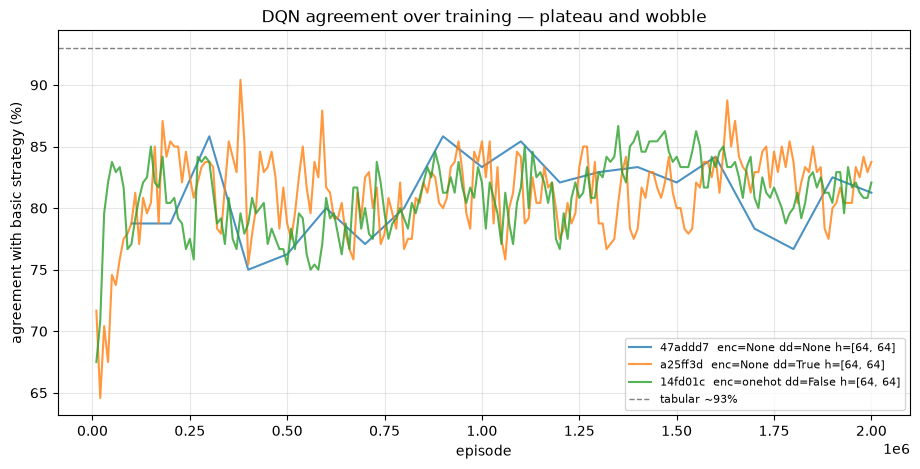

In [5]:
plt.figure(figsize=(11,5))
for r in RECORDS:
    if not is_dqn(r): continue
    lc = r.get("learning_curve", [])
    xs = [p["episode"] for p in lc if p.get("agreement") is not None]
    ys = [p["agreement"]*100 for p in lc if p.get("agreement") is not None]
    if not xs: continue
    c = r["config"]
    lbl = f'{r["_id"][-7:]}  enc={c.get("encoding")} dd={c.get("double_dqn")} h={c.get("hidden")}'
    plt.plot(xs, ys, alpha=.8, label=lbl)
plt.axhline(93, ls="--", c="gray", lw=1, label="tabular ~93%")
plt.xlabel("episode"); plt.ylabel("agreement with basic strategy (%)")
plt.title("DQN agreement over training — plateau and wobble"); plt.grid(alpha=.3); plt.legend(fontsize=8)
plt.show()

## 4. What *kind* of errors? (genuine disagreements by direction)\n\nIf it were one-directional **overestimation**, the net would systematically over-commit to one action. Check whether that holds.

In [6]:
def err_breakdown(r):
    gen = [c for c in r["diff"]["cells"] if c["category"]=="genuine_disagreement"]
    over  = sum(1 for c in gen if c["agent_action"]=="double" and c["basic_action"]!="double")
    under = sum(1 for c in gen if c["basic_action"]=="double" and c["agent_action"]!="double")
    overhit = sum(1 for c in gen if c["basic_action"]=="stand" and c["agent_action"]=="hit")
    return {"genuine": len(gen), "over_double": over, "under_double": under,
            "over_hit": overhit, "other": len(gen)-over-under-overhit}

rows = []
for r in RECORDS:
    if is_dqn(r):
        c = r["config"]
        rows.append({"id": r["_id"][-7:], "enc": c.get("encoding"), "dd": c.get("double_dqn"),
                     "h": str(c.get("hidden")), "ep": c.get("num_episodes"), **err_breakdown(r)})
pd.DataFrame(rows)

,id,enc,dd,h,ep,genuine,over_double,under_double,over_hit,other
0,15f8a9b,NaN,None,"[64, 64]",300000,46,29,4,12,1
1,47addd7,NaN,None,"[64, 64]",2000000,43,17,8,15,3
2,a25ff3d,NaN,True,"[64, 64]",2000000,38,20,2,13,3
3,14fd01c,onehot,False,"[64, 64]",2000000,43,12,18,12,1


**Read:** the errors run **both directions** (over- *and* under-double, plus over-hit) — not a clean overestimation bias. One-hot mostly **relocates** over→under double, leaving the total unchanged.

## 5. Are disagreements in *rare* cells? (the coverage signature)\n\nUse a tabular run's per-cell visit counts as a natural-play frequency proxy, and compare agree vs genuine-disagree cells.

frequency proxy from tabular run: 305b302
target DQN run: 14fd01c (one-hot)
  AGREE   median visits: 18,783
  GENUINE median visits: 7,239   (~2.6x rarer)


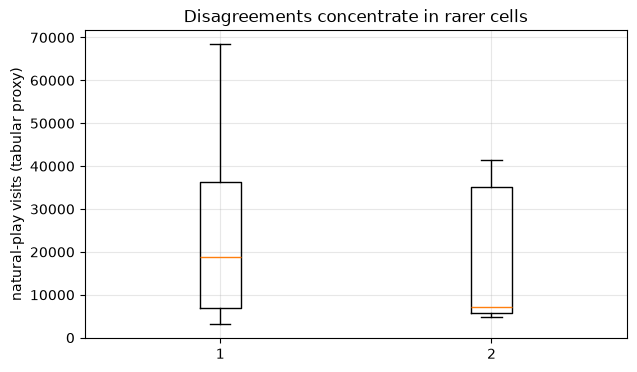

In [12]:
def tabular_visits():
    for r in RECORDS:
        if not is_dqn(r) and "qtable" in r:
            vis = {}
            for row in r["qtable"]:
                k = (row["player_value"], bool(row["is_soft"]), row["dealer_upcard"])
                vis[k] = vis.get(k, 0) + int(row["n"])
            return r["_id"][-7:], vis
    return None, {}

src_id, VIS = tabular_visits()
print("frequency proxy from tabular run:", src_id)

def rarity(r):
    agree, gen = [], []
    for c in r["diff"]["cells"]:
        v = VIS.get((c["player_value"], c["is_soft"], c["dealer_upcard"]), 0)
        (gen if c["category"]=="genuine_disagreement" else agree).append(v)
    return agree, gen

target = next(r for r in RECORDS if is_dqn(r) and r["config"].get("encoding")=="onehot")
agree, gen = rarity(target)
print("target DQN run:", target["_id"][-7:], "(one-hot)")
print(f"  AGREE   median visits: {int(st.median(agree)):,}")
print(f"  GENUINE median visits: {int(st.median(gen)):,}   (~{st.median(agree)/max(st.median(gen),1):.1f}x rarer)")

plt.figure(figsize=(7,4))
plt.boxplot([agree, gen], label=["agree","genuine disagree"], showfliers=False)
plt.ylabel("natural-play visits (tabular proxy)")
plt.title("Disagreements concentrate in rarer cells"); plt.grid(alpha=.3); plt.show()

### The rarest disagreements

In [8]:
pairs = []
for c in target["diff"]["cells"]:
    if c["category"]=="genuine_disagreement":
        v = VIS.get((c["player_value"], c["is_soft"], c["dealer_upcard"]), 0)
        pairs.append((v, c))
print("rarest genuine-disagreement cells (lowest natural frequency):")
for v, c in sorted(pairs)[:12]:
    k = "soft" if c["is_soft"] else "hard"
    print(f'  {k} {c["player_value"]:>2} v{c["dealer_upcard"]:<2}  visits~{v:>7,}   net={c["agent_action"]:6} basic={c["basic_action"]}')

rarest genuine-disagreement cells (lowest natural frequency):
  soft 13 v6   visits~  4,805   net=hit    basic=double
  soft 13 v5   visits~  4,827   net=hit    basic=double
  soft 14 v6   visits~  4,990   net=hit    basic=double
  soft 14 v5   visits~  5,044   net=hit    basic=double
  soft 15 v4   visits~  5,059   net=hit    basic=double
  soft 15 v5   visits~  5,132   net=hit    basic=double
  soft 16 v5   visits~  5,134   net=hit    basic=double
  soft 16 v6   visits~  5,472   net=hit    basic=double
  soft 15 v6   visits~  5,558   net=hit    basic=double
  soft 16 v4   visits~  5,616   net=hit    basic=double
  soft 20 v4   visits~  5,831   net=double basic=stand
  soft 17 v5   visits~  5,865   net=stand  basic=double


## 6. The over-doubling Q-values vs the *true* EV\n\nThe net's own Q for `double` on soft hands is implausibly high (no real double exceeds ~+0.6). Next cell measures the true EV from the engine.

In [9]:
od = [c for c in target["diff"]["cells"]
      if c["category"]=="genuine_disagreement" and c["agent_action"]=="double" and c["basic_action"]!="double"]
od.sort(key=lambda c: -(c["agent_q"]-c["basic_q"]))
print("over-double cells — net Q(double) vs Q(basic's action):")
for c in od[:10]:
    k = "soft" if c["is_soft"] else "hard"
    print(f'  {k} {c["player_value"]} v{c["dealer_upcard"]}: Q(double)={c["agent_q"]:+.3f}  Q({c["basic_action"]})={c["basic_q"]:+.3f}')

over-double cells — net Q(double) vs Q(basic's action):
  soft 20 v8: Q(double)=+1.456  Q(stand)=+0.839
  soft 20 v5: Q(double)=+1.387  Q(stand)=+0.810
  soft 20 v4: Q(double)=+1.354  Q(stand)=+0.796
  soft 20 v3: Q(double)=+1.225  Q(stand)=+0.743
  soft 20 v6: Q(double)=+1.115  Q(stand)=+0.697
  soft 19 v8: Q(double)=+1.071  Q(stand)=+0.679
  soft 20 v7: Q(double)=+0.890  Q(stand)=+0.604
  soft 19 v6: Q(double)=+0.799  Q(stand)=+0.566
  soft 19 v3: Q(double)=+0.601  Q(stand)=+0.484
  soft 19 v4: Q(double)=+0.584  Q(stand)=+0.477


## 7. Engine sanity check — doubles really pay ±2 (rules out a reward bug)\n\nForce doubles through the Phase-2 engine and inspect realized payouts. Confirms the reward wiring and gives the **true** EV of doubling soft 20.

In [10]:
import random
from simulator.card import Deck
from simulator.config import vegas_strip
from simulator.hand_simulator import HandSimulator
from strategies.base import Strategy

class AlwaysDouble(Strategy):
    def decide(self, s): return "double" if s.can_double else "stand"

random.seed(0)
cfg = vegas_strip(); cfg.card_counting_allowed = False
allp, soft20 = [], []
for _ in range(40000):
    res = HandSimulator(cfg, Deck(num_decks=cfg.num_decks), AlwaysDouble()).play_hand(
        session_id="x", bankroll=0.0, bet_size=1.0, hands_played=0)
    recs = [r for r in res.decision_records if r.action != "none"]
    if recs and recs[0].action == "double":
        allp.append(res.payout)
        if recs[0].player_value == 20 and recs[0].player_is_soft:
            soft20.append(res.payout)
print("doubled-hand payouts (distinct):", sorted(set(allp)))
print(f"mean payout, indiscriminate doubling: {st.mean(allp):+.3f}  (correctly terrible)")
print(f"mean payout, doubling soft 20:        {st.mean(soft20):+.3f}  <- TRUE EV; the net believed ~+1.4")

doubled-hand payouts (distinct): [-2.0, 0.0, 2.0]
mean payout, indiscriminate doubling: -0.729  (correctly terrible)
mean payout, doubling soft 20:        +0.272  <- TRUE EV; the net believed ~+1.4


## 8. Policy heatmap — where the one-hot DQN disagrees\n\nGreen = agrees with basic strategy, yellow = near-tie, red = genuine disagreement. Letters = the net's action (H/S/D).

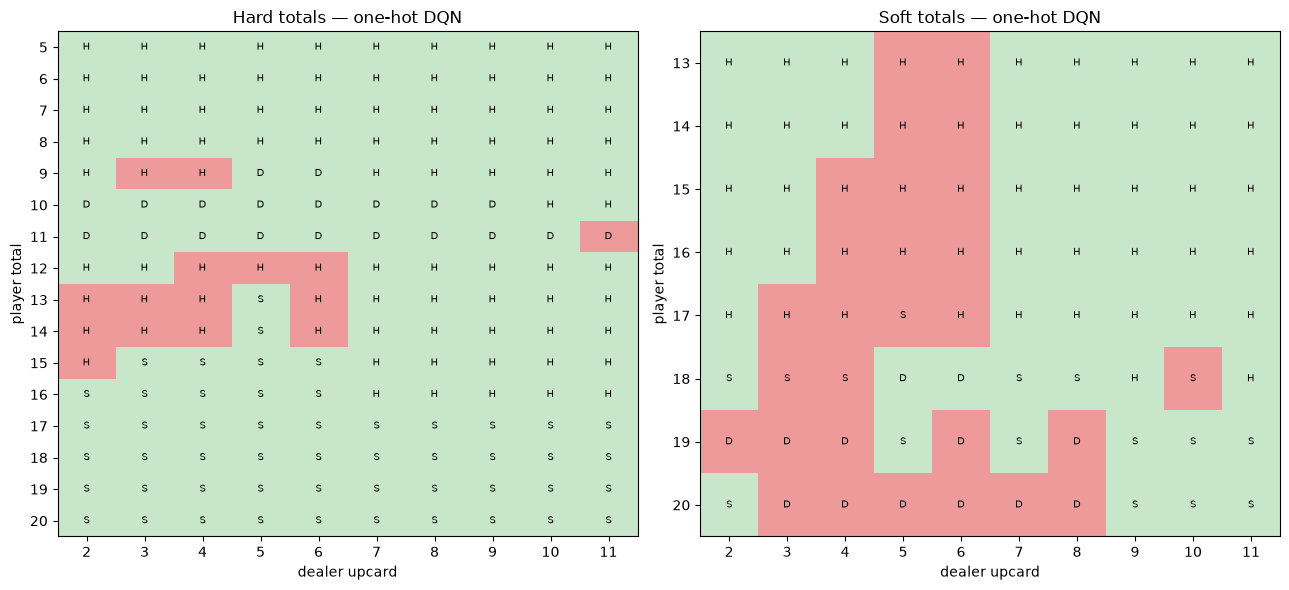

In [11]:
from matplotlib.colors import ListedColormap
ACT = {"hit":"H","stand":"S","double":"D","split":"P","surrender":"R"}
CATC = {"agree":0,"near_equal_ev":1,"genuine_disagreement":2,"under_visited":3}
cmap = ListedColormap(["#c8e6c9","#ffe082","#ef9a9a","#e0e0e0"])

def heat(cells, is_soft, ax, title):
    vals = sorted({c["player_value"] for c in cells if c["is_soft"]==is_soft})
    ups = list(range(2,12))
    grid = np.full((len(vals), len(ups)), np.nan); lab = {}
    for c in cells:
        if c["is_soft"]!=is_soft: continue
        i, j = vals.index(c["player_value"]), ups.index(c["dealer_upcard"])
        grid[i,j] = CATC[c["category"]]; lab[(i,j)] = ACT.get(c["agent_action"],"?")
    ax.imshow(grid, cmap=cmap, vmin=0, vmax=3, aspect="auto")
    ax.set_xticks(range(len(ups))); ax.set_xticklabels(ups)
    ax.set_yticks(range(len(vals))); ax.set_yticklabels(vals)
    ax.set_xlabel("dealer upcard"); ax.set_ylabel("player total"); ax.set_title(title)
    for (i,j),t in lab.items(): ax.text(j,i,t,ha="center",va="center",fontsize=7)

cells = target["diff"]["cells"]
fig, axes = plt.subplots(1,2, figsize=(13,6))
heat(cells, False, axes[0], "Hard totals — one-hot DQN")
heat(cells, True,  axes[1], "Soft totals — one-hot DQN")
plt.tight_layout(); plt.show()

## Findings so far (verified)

- **DQN plateaus at ~82%** agreement (vs tabular ~93%), at ~1.9–2.2% house edge — and it's **not under-trained** (the agreement curve is flat across 0.3M→2M, not climbing).
- **Not bias** (Double DQN didn't move it), **not capacity** (256,256 didn't), **not encoding** (one-hot just *relocated* errors), **not a bug** (engine pays doubles ±2; realized soft-20-double EV ≈ +0.30).
- **Errors are two-directional** miscalibration — over- *and* under-double, plus over-hit — and they **concentrate in rare cells** (genuine-disagree cells are seen ~2.6× less often than agree cells), led by the **rare soft-hand** decisions.
- **The mechanism:** where the tabular agent left rare cells honestly blank ("under-visited"), the network **fills them with confident extrapolation** that's often wrong — sampling imbalance × function approximation, hardest where the EV gap is small.
- **Next (falsifiable):** exploring-starts-for-DQN — force coverage of every (state, action) start. If the rare-cell errors clear and the soft-double Q-values fall to truth, coverage is confirmed; if not, it's the boundary-precision floor. Mirrors the Problem A capstone.

In [13]:
# True EV (engine) vs net Q for stand and double, soft 19/20 — is only `double` miscalibrated?
import random
from collections import defaultdict
from simulator.card import Deck
from simulator.config import vegas_strip
from simulator.hand_simulator import HandSimulator
from strategies.base import Strategy
cfg = vegas_strip(); cfg.card_counting_allowed = False
def measure(strat, N=120000):
    random.seed(1); by = defaultdict(list)
    for _ in range(N):
        res = HandSimulator(cfg, Deck(num_decks=cfg.num_decks), strat).play_hand(
            session_id="x", bankroll=0.0, bet_size=1.0, hands_played=0)
        rc = [r for r in res.decision_records if r.action != "none"]
        if rc and rc[0].player_is_soft and rc[0].player_value in (19,20):
            by[(rc[0].player_value, rc[0].dealer_upcard)].append(res.payout)
    return by
class AllStand(Strategy):
    def decide(self, s): return "stand"
class DblSoft(Strategy):
    def decide(self, s): return "double" if (s.can_double and s.player_is_soft and s.player_value in (19,20)) else "stand"
stand, dbl = measure(AllStand()), measure(DblSoft())
agg = lambda by, v: st.mean([p for (vv,u),ps in by.items() if vv==v for p in ps])
netq = {(c["player_value"], c["dealer_upcard"]): (c["agent_q"], c["basic_q"])
        for c in target["diff"]["cells"]
        if c["is_soft"] and c["player_value"] in (19,20) and c["agent_action"]=="double" and c["basic_action"]=="stand"}
for v in (20, 19):
    cells = [k for k in netq if k[0]==v]
    qs = st.mean(netq[k][1] for k in cells); qd = st.mean(netq[k][0] for k in cells)
    print(f"soft {v}: stand true {agg(stand,v):+.3f} / net {qs:+.3f} (err {qs-agg(stand,v):+.3f}) | "
          f"double true {agg(dbl,v):+.3f} / net {qd:+.3f} (err {qd-agg(dbl,v):+.3f})")

soft 20: stand true +0.663 / net +0.748 (err +0.085) | double true +0.251 / net +1.238 (err +0.987)
soft 19: stand true +0.324 / net +0.535 (err +0.211) | double true +0.149 / net +0.710 (err +0.561)
